In [1]:
import pandas as pd
import seaborn
from matplotlib import pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv("sbc_shap_res.csv", sep = ";")

In [3]:
data["Analysis type"] = data["Analysis type"].ffill(axis =0)

In [4]:
for id, group in data.groupby("Analysis type"):
    print(group["Internal AUROC"].values.squeeze().shape)

(4,)
(4,)
(4,)
(4,)
(4,)
(4,)
(4,)


In [5]:
from IPython.display import HTML, display
for id, group in data.groupby("Analysis type"):
    display(HTML(group.to_html(index=False)))
    print(group.max(axis = 0))

Analysis type,Machine learning model,Internal AUROC,External AUROC,Internal sensitivity,External sensitivity
No time series analysis,Logistic regression,0.837,0.755,0.704,0.580
No time series analysis,Decision Tree,0.841,0.790,0.749,0.647
No time series analysis,Random Forest,0.870,0.818,0.770,0.654
No time series analysis,XGBoost,0.875,0.807,0.782,0.654


Analysis type             No time series analysis
Machine learning model                    XGBoost
Internal AUROC                              0.875
External AUROC                              0.818
Internal sensitivity                        0.782
External sensitivity                        0.654
dtype: object


Analysis type,Machine learning model,Internal AUROC,External AUROC,Internal sensitivity,External sensitivity
Prospective time series analysis,Logistic regression,0.841,0.757,0.724,0.592
Prospective time series analysis,Decision Tree,0.850,0.792,0.788,0.652
Prospective time series analysis,Random Forest,0.889,0.839,0.808,0.721
Prospective time series analysis,XGBoost,0.888,0.838,0.814,0.705


Analysis type             Prospective time series analysis
Machine learning model                             XGBoost
Internal AUROC                                       0.889
External AUROC                                       0.839
Internal sensitivity                                 0.814
External sensitivity                                 0.721
dtype: object


Analysis type,Machine learning model,Internal AUROC,External AUROC,Internal sensitivity,External sensitivity
Prospective time-series analysis with difference to mean reference node,Logistic regression,0.849,0.776,0.731,0.610
Prospective time-series analysis with difference to mean reference node,Decision Tree,0.842,0.790,0.731,0.670
Prospective time-series analysis with difference to mean reference node,Random Forest,0.892,0.841,0.816,0.737
Prospective time-series analysis with difference to mean reference node,XGBoost,0.896,0.839,0.829,0.703


...

Analysis type             Prospective time-series analysis with quotient...
Machine learning model                                              XGBoost
Internal AUROC                                                        0.895
External AUROC                                                        0.843
Internal sensitivity                                                  0.833
External sensitivity                                                  0.721
dtype: object


Analysis type,Machine learning model,Internal AUROC,External AUROC,Internal sensitivity,External sensitivity
Prospective time-series analysis with quotient to median reference node,Logistic regression,0.855,0.781,0.743,0.618
Prospective time-series analysis with quotient to median reference node,Decision Tree,0.856,0.805,0.777,0.672
Prospective time-series analysis with quotient to median reference node,Random Forest,0.888,0.836,0.806,0.717
Prospective time-series analysis with quotient to median reference node,XGBoost,0.893,0.835,0.816,0.703


Analysis type             Prospective time-series analysis with quotient...
Machine learning model                                              XGBoost
Internal AUROC                                                        0.893
External AUROC                                                        0.836
Internal sensitivity                                                  0.816
External sensitivity                                                  0.717
dtype: object


Analysis type,Machine learning model,Internal AUROC,External AUROC,Internal sensitivity,External sensitivity
Retrospective time-series analysis,Logistic regression,0.851,0.783,0.731,0.632
Retrospective time-series analysis,Decision Tree,0.927,0.925,0.902,0.917
Retrospective time-series analysis,Random Forest,0.943,0.953,0.927,0.944
Retrospective time-series analysis,XGBoost,0.943,0.955,0.924,0.940


Analysis type             Retrospective time-series analysis
Machine learning model                               XGBoost
Internal AUROC                                         0.943
External AUROC                                         0.955
Internal sensitivity                                   0.927
External sensitivity                                   0.944
dtype: object


In [6]:
data["Analysis type"].unique()

array(['No time series analysis', 'Prospective time series analysis',
       'Prospective time-series analysis with difference to mean reference node ',
       'Prospective time-series analysis with difference to median reference node ',
       'Prospective time-series analysis with quotient to mean reference node ',
       'Prospective time-series analysis with quotient to median reference node ',
       'Retrospective time-series analysis'], dtype=object)

In [7]:
analysis_type_dict = {
    'No time series analysis': "baseline", 'Prospective time series analysis': "prosp. time-series",
       'Prospective time-series analysis with difference to mean reference node ': "Mean node (diff.)",
       'Prospective time-series analysis with difference to median reference node ': "Median node (diff.)",
       'Prospective time-series analysis with quotient to mean reference node ': "Mean node (quot.)",
       'Prospective time-series analysis with quotient to median reference node ': "Median node (quot.)",
       'Retrospective time-series analysis': "retrsp. time-series"
}

In [8]:
column_idx_to_label = {i: data.columns[i] for i in range(len(data.columns))}

Decision Tree
0.841
Logistic regression
0.837
Random Forest
0.87
XGBoost
0.875


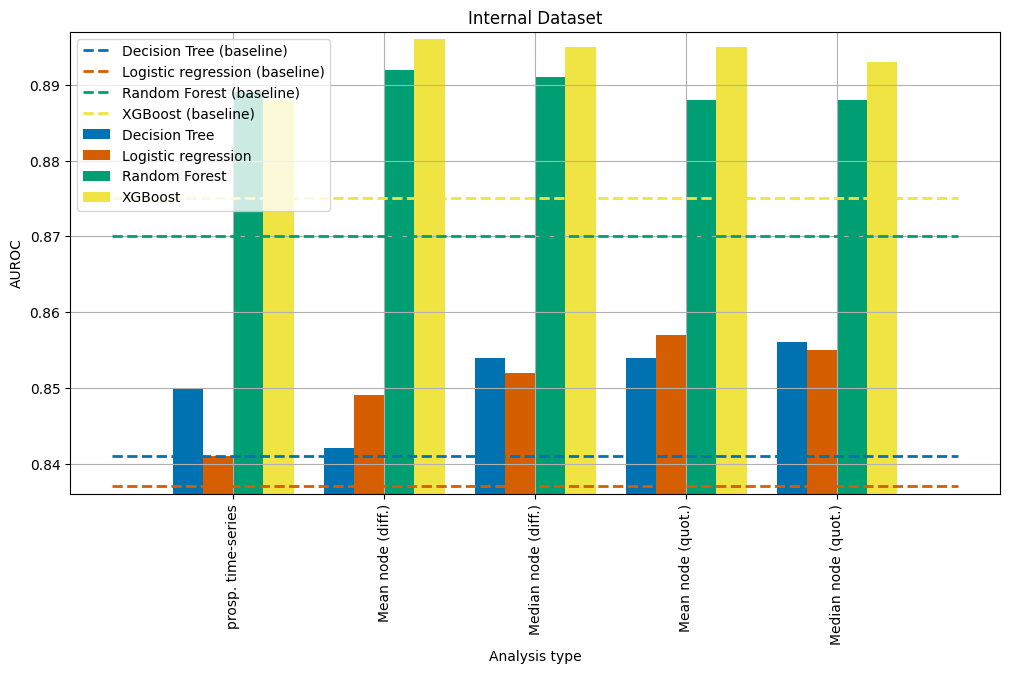

In [9]:
plt.figure(figsize=(12, 6))
eps = .001
min_val = float(1.0)
max_val = float(0.0)
colors = ['#0072B2', '#D55E00', '#009E73', '#F0E442']
for idx, (id, group) in enumerate(data.groupby("Machine learning model")):
    
    labels = group.iloc[:, 0]
    labels = labels[:-1].values.tolist()    
    internal_auroc = group.iloc[:-1, 2].values.tolist()
    
    min_val = min([min_val, min(internal_auroc)])
    max_val = max([max_val, max(internal_auroc)])      
    
    baseline_auroc = internal_auroc.pop(0)
    baseline_label = labels.pop(0)
    print(id)
    print(baseline_auroc)
    
    bar_width = .2
    offset = (idx - (4 - 1) / 2) * bar_width
    labels_axis = np.arange(len(labels))
      
    plt.bar(labels_axis + offset, internal_auroc, bar_width, label = id, color=colors[idx])
    plt.hlines(
            baseline_auroc,  
            xmin=0 - bar_width*4,  # Start of the line
            xmax=0 + bar_width*4*6,  # End of the line
            linestyle="dashed", label=f"{id} (baseline)",
        linewidth=2,
        color=colors[idx]
        )
    

plt.grid(which = "both")
plt.ylim(min_val - eps, max_val + eps)
plt.legend()
plt.title("Internal Dataset")
plt.ylabel("AUROC")
plt.xlabel("Analysis type")

plt.xticks(labels_axis, list(map(lambda label: analysis_type_dict[label], labels)), rotation=90)
plt.show()

In [14]:
from math import floor, ceil 
def plot_column(axs, column_idx):
    subplot_idx = column_idx-2
    eps = .001
    min_val = float(1.0)
    max_val = float(0.0)
    colors = ['#0072B2', '#D55E00', '#009E73', '#F0E442']
    for machine_learning_model_idx, (id, group) in enumerate(data.groupby("Machine learning model")):
        
        labels = group.iloc[:, 0]
        labels = labels[:-1].values.tolist()    
        internal_auroc = group.iloc[:-1, column_idx].values.tolist()
        
        min_val = min([min_val, floor(min(internal_auroc)*100)/100])
        max_val = max([max_val, ceil(max(internal_auroc)*100)/ 100])      
        
        bar_width = .2
        offset = (machine_learning_model_idx - (4 - 1) / 2) * bar_width
        labels_axis = np.arange(len(labels))
          
        axs[subplot_idx // 2, subplot_idx % 2].bar(labels_axis + offset, internal_auroc, bar_width, label = id, color=colors[machine_learning_model_idx], hatch="/"*(machine_learning_model_idx+1))
    
        
    
    axs[subplot_idx // 2, subplot_idx % 2].grid(which = "both")
    # axs[subplot_idx // 2, subplot_idx % 2].annotate('', xy=(0, min_val + (max_val - min_val)/2), xycoords=('axes fraction', 'data'), annotation_clip=False)
    # axs[subplot_idx // 2, subplot_idx % 2].set_ylim(min_val, max_val)
    axs[subplot_idx // 2, subplot_idx % 2].set_yscale('log')
    #plt.legend()
    
    column_label = column_idx_to_label[column_idx]
    column_label_split = column_label.split(" ")
    y_label = column_label_split[-1]
    if "sensitivity" in y_label:
        y_label = "Sensitivity [%]"
    axs[subplot_idx // 2, subplot_idx % 2].set_title(f"{column_label_split[0]} Dataset")
    axs[subplot_idx // 2, subplot_idx % 2].set_ylabel(y_label)
    axs[subplot_idx // 2, subplot_idx % 2].set_xlabel("Analysis type")
    axs[subplot_idx // 2, subplot_idx % 2].set_xticks(labels_axis, list(map(lambda label: analysis_type_dict[label], labels)), rotation=90)
    

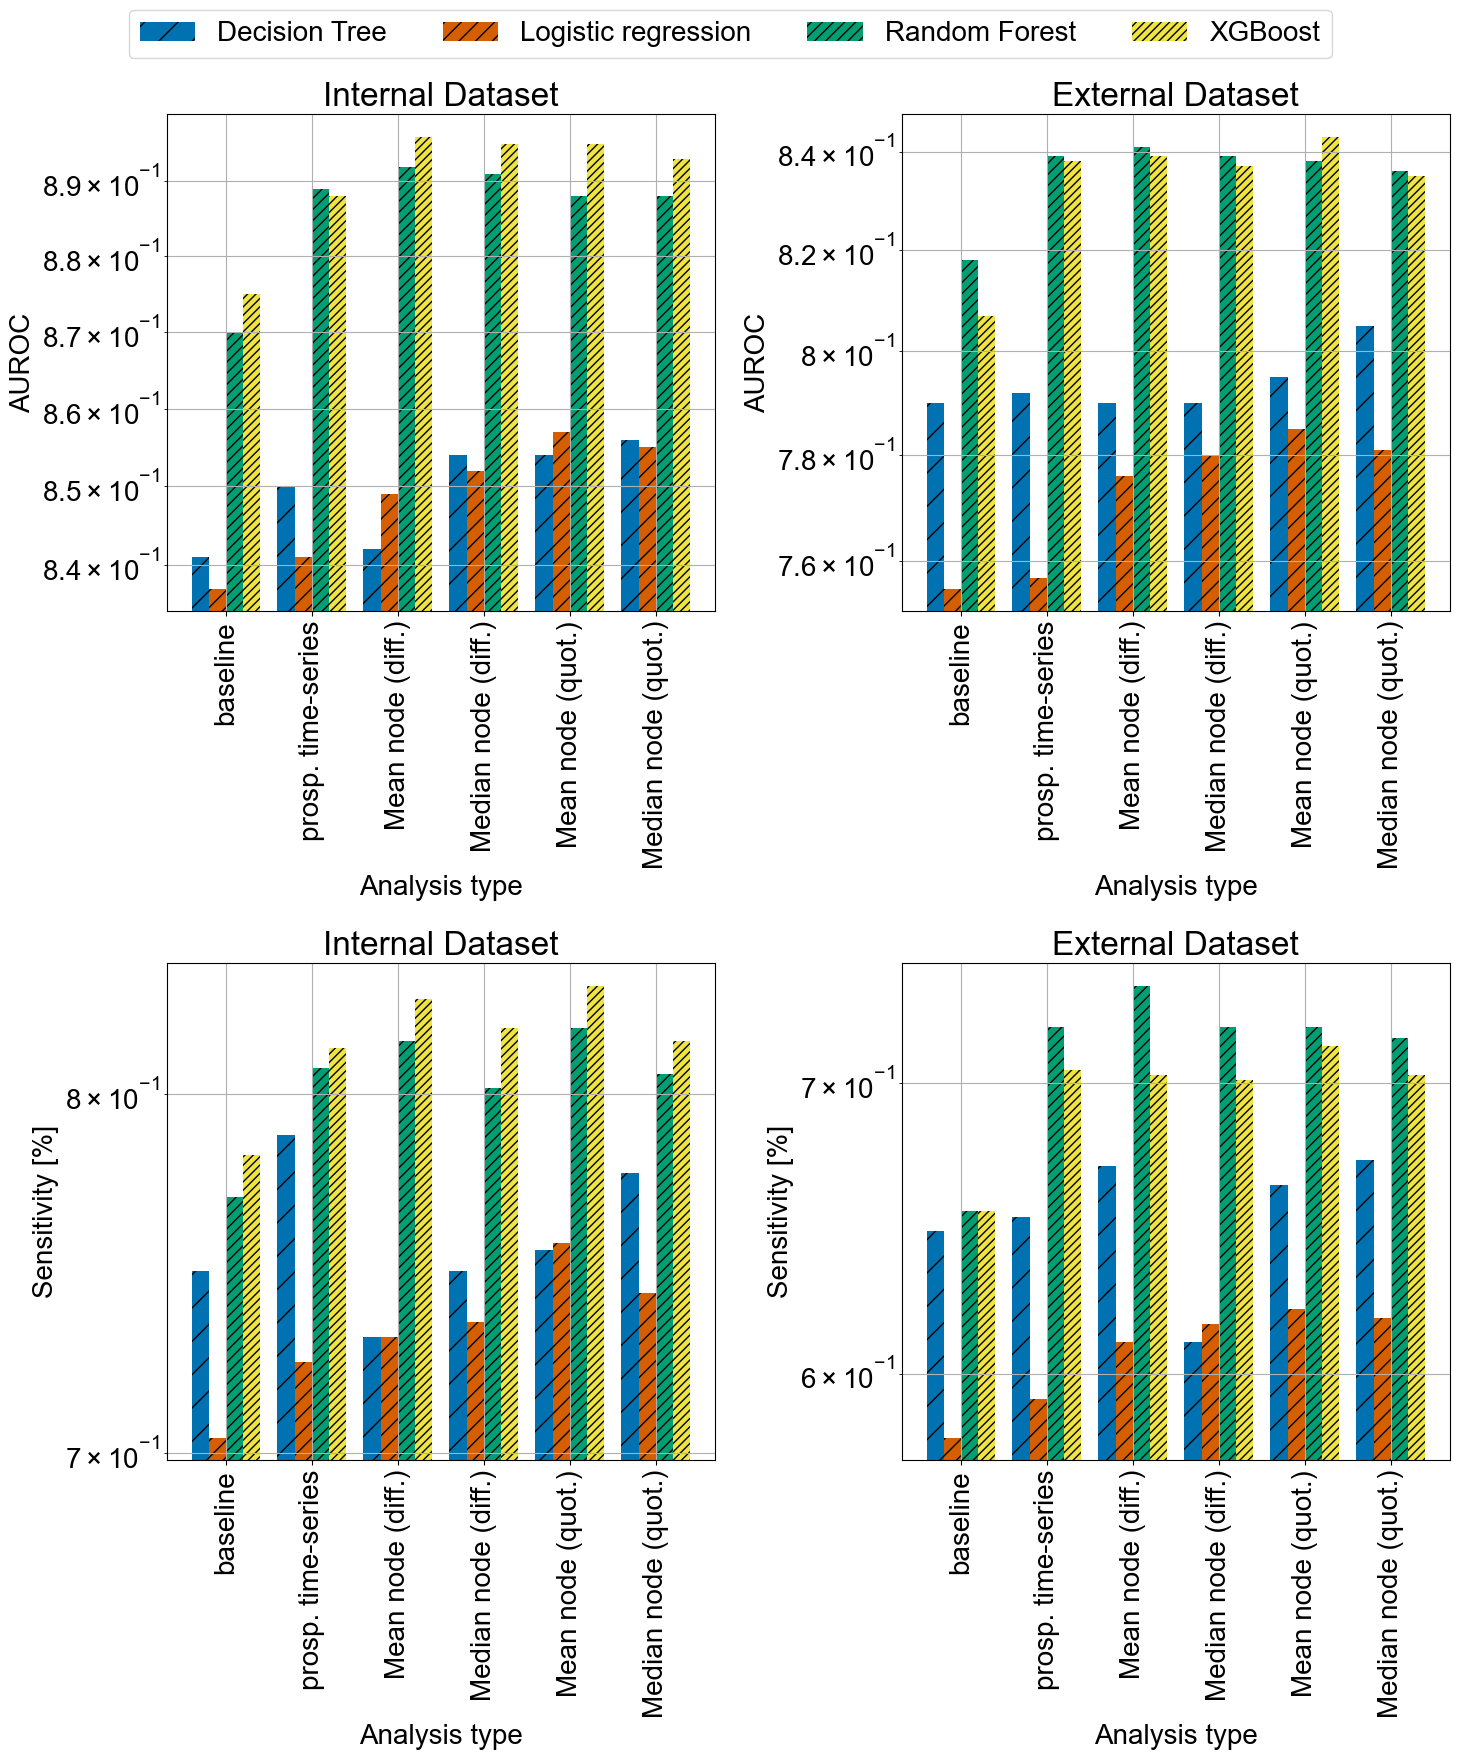

In [48]:
plt.rcParams.update({'font.family': 'arial', 'font.size': 20})
fig, axs = plt.subplots(2, 2, figsize=(15, 18))
for i in range(4): 
    plot_column(axs, i + 2)

# Create a legend inside the new axis
handles, labels = [], []
for ax in axs.flat:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle)
            labels.append(label)
fig.legend(handles, labels, loc='center', fontsize=20, bbox_to_anchor=(0.5, 0.97), ncol=4)
plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.subplots_adjust(top=1)
plt.savefig("metrics.svg")
plt.show()

## Doppelstrich auf y-achse um anzuziegen dass es nicht bei 0 anfängt

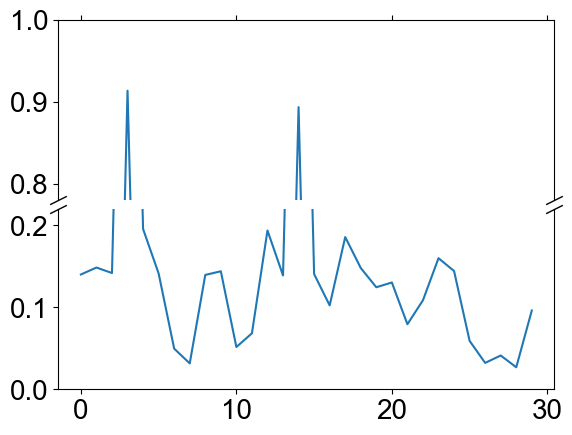

In [12]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(19680801)
pts = np.random.rand(30)*.2
pts[[3, 14]] += .8

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig.subplots_adjust(hspace=0.05)  # adjust space between Axes

# plot the same data on both Axes
ax1.plot(pts)
ax2.plot(pts)

# zoom-in / limit the view to different portions of the data
ax1.set_ylim(.78, 1.)  # outliers only
ax2.set_ylim(0, .22)  # most of the data

# hide the spines between ax and ax2
ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # don't put tick labels at the top
ax2.xaxis.tick_bottom()
.

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

plt.show()